For Fig. 2E

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(stringr)
    library(Seurat)
    library(dplyr)
    library(SingleCellExperiment)
    library(SummarizedExperiment)
    library(HDF5Array)
    library(DelayedArray)
    library(Matrix)
    library(showtext)
    library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100) 

In [2]:
WD <- "data/"
sample <- "filtered_counts_SELECTseq_200000.rds"
adata <- readRDS(paste0(WD, sample))
adata

An object of class Seurat 
31360 features across 245 samples within 1 assay 
Active assay: RNA (31360 features, 0 variable features)
 1 layer present: counts

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


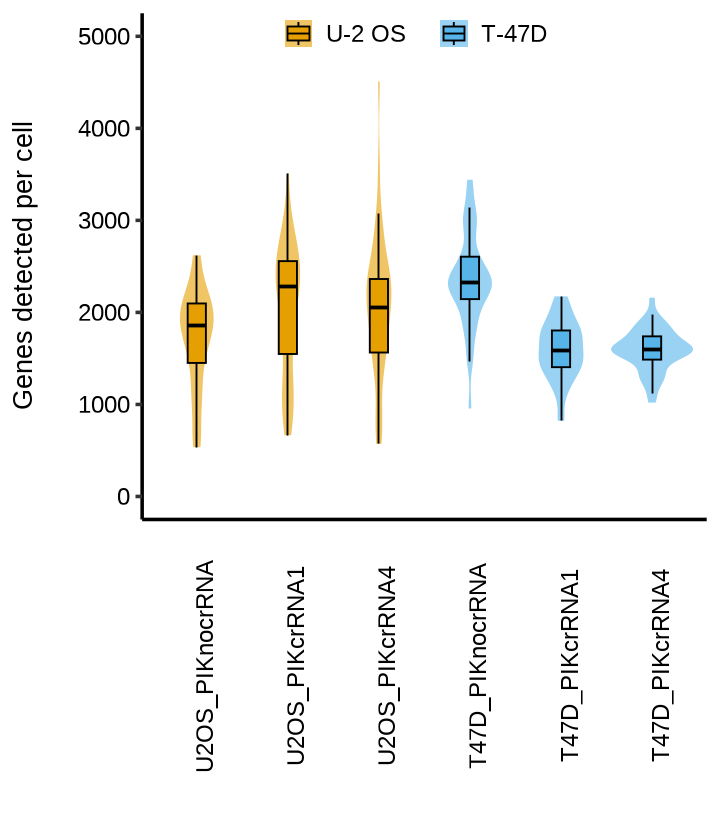

In [3]:
options(repr.plot.width = 6, repr.plot.height =7)
df <- adata@meta.data
df$cell_line <- factor(df$cell_line, levels = c("U2OS", "T47D"))
df$sample_group <- factor(df$sample_group, levels = c("U2OS_PIKnocrRNA", "U2OS_PIKcrRNA1", "U2OS_PIKcrRNA4", "T47D_PIKnocrRNA", "T47D_PIKcrRNA1", "T47D_PIKcrRNA4"))

ggplot(df, aes(x = sample_group, y = nFeature_RNA, fill = cell_line)) +
  

  geom_violin(trim = TRUE, alpha = 0.6, color = NA) +

  geom_boxplot(width = 0.2,
               outlier.shape = NA,
               alpha = 1,
               color = "black",
               linewidth = 0.4) +

  scale_fill_manual(values = c("U2OS" = "#E69F00",
                               "T47D" = "#56B4E9"),
                    labels = c(
      "U2OS" = "U-2 OS",
      "T47D" = "T-47D")) +

  labs(
    x = "",
    y = "Genes detected per cell"
  ) +

  theme_bw(base_size = 16) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.text.x = element_text(size = 18, color = "black", angle = 90),
    axis.text.y = element_text(size = 18, color = "black"),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_line(linewidth = 0.75),
    axis.title.y = element_text(size = 20, margin = margin(r = 15)),
    legend.position = c(0.5, 0.96),
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    legend.title = element_blank(),
    legend.direction = "horizontal",
    legend.text = element_text(size = 18, color = "black")
  ) +
  ylim(0,5000)
ggsave("data/number_of_genes at 200k.pdf", plot = last_plot(), width = 6, height = 7, units = "in", dpi = 300)

In [4]:
table(df$sample_group)


U2OS_PIKnocrRNA  U2OS_PIKcrRNA1  U2OS_PIKcrRNA4 T47D_PIKnocrRNA  T47D_PIKcrRNA1 
             39              45              41              40              40 
 T47D_PIKcrRNA4 
             40 

In [5]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] showtext_0.9-7              showtextdb_3.0             
 [3] sysfonts_0.8.9              HDF5Array_1.30.1           
 [5] rhdf5_2.46.1                DelayedArray_0.28.0        
 [7] SparseArray_1.2.4           S4Arrays_1.2.1             
 [9] abind_1.4-8                 Matrix_1.6-5         